In [1]:
import main_program as mp
import sys
import os
internal_WSM_dir = os.getcwd()
internal_PDC_dir = os.path.abspath(os.path.join(internal_WSM_dir, '..'))
root_dir = os.path.abspath(os.path.join(internal_PDC_dir, '..'))
internal_CP_dir = os.path.abspath(os.path.join(root_dir, '6_Common_Paramaters'))
sys.path.append(internal_CP_dir)
import Common_Params as CP
import matplotlib.pyplot as plt
import pickle

In [2]:
def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp, title):
    fig, axes = plt.subplots(1, 3, figsize = (90, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(3):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness
    
    sri_1 = store_times[0].index(store_start_reaction_times)

    axes[0].plot(store_times[0], store_seperations[0], label = f'min : {round(min(store_seperations[0]), 2)}, saturation : {round(store_seperations[0][-1], 2)}', color = 'blue', linewidth = 4)
    axes[0].plot(store_times[0][sri_1:], [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[0][sri_1:]], label = f'Desired final seperation : {round(CP.Dd + CP.Td * store_velocities[0][-1] * 5 / 18, 2)}', color = 'green', linewidth = 4)
    axes[0].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    axes[0].set_title(title, fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(store_times[0], store_velocities[0], label = f'max : {round(max(store_velocities[0]), 2)}, saturation : {round(store_velocities[0][-1], 2)}', color = 'blue', linewidth = 4)
    axes[1].plot(store_times[0][sri_1:], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))][sri_1:], label = f'Desired final velocity : {round(Vp * 18 / 5, 2)} km/hr', color = 'green', linewidth = 4)
    axes[1].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    axes[1].set_title(title, fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    axes[2].plot(store_times[0], store_accelerations[0], label = f'min : {round(min(store_accelerations[0]), 2)}, max : {round(max(store_accelerations[0]), 2)}', color = 'blue', linewidth = 4)
    axes[2].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
    axes[2].grid(True, linewidth = 4.0)
    axes[2].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[2].set_ylabel('Acceleration [m/s^2]', fontsize = font, fontweight = 'bold')
    axes[2].set_title(title, fontsize = font, fontweight = 'bold')
    axes[2].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[2].legend(fontsize = font)

    plt.show()

In [3]:
store_separations, store_accelerations, store_velocities, store_times, store_detected_times, store_start_reaction_times = mp.main(0.05)

In [4]:
titles = ['Cut in scenario (Scenario 1)', ' Slower preceding vehicle scenario (Scenario 2)', 'Complete stopping scenario (Scenario 3)', 'Cut in scenario (Scenario 1)']

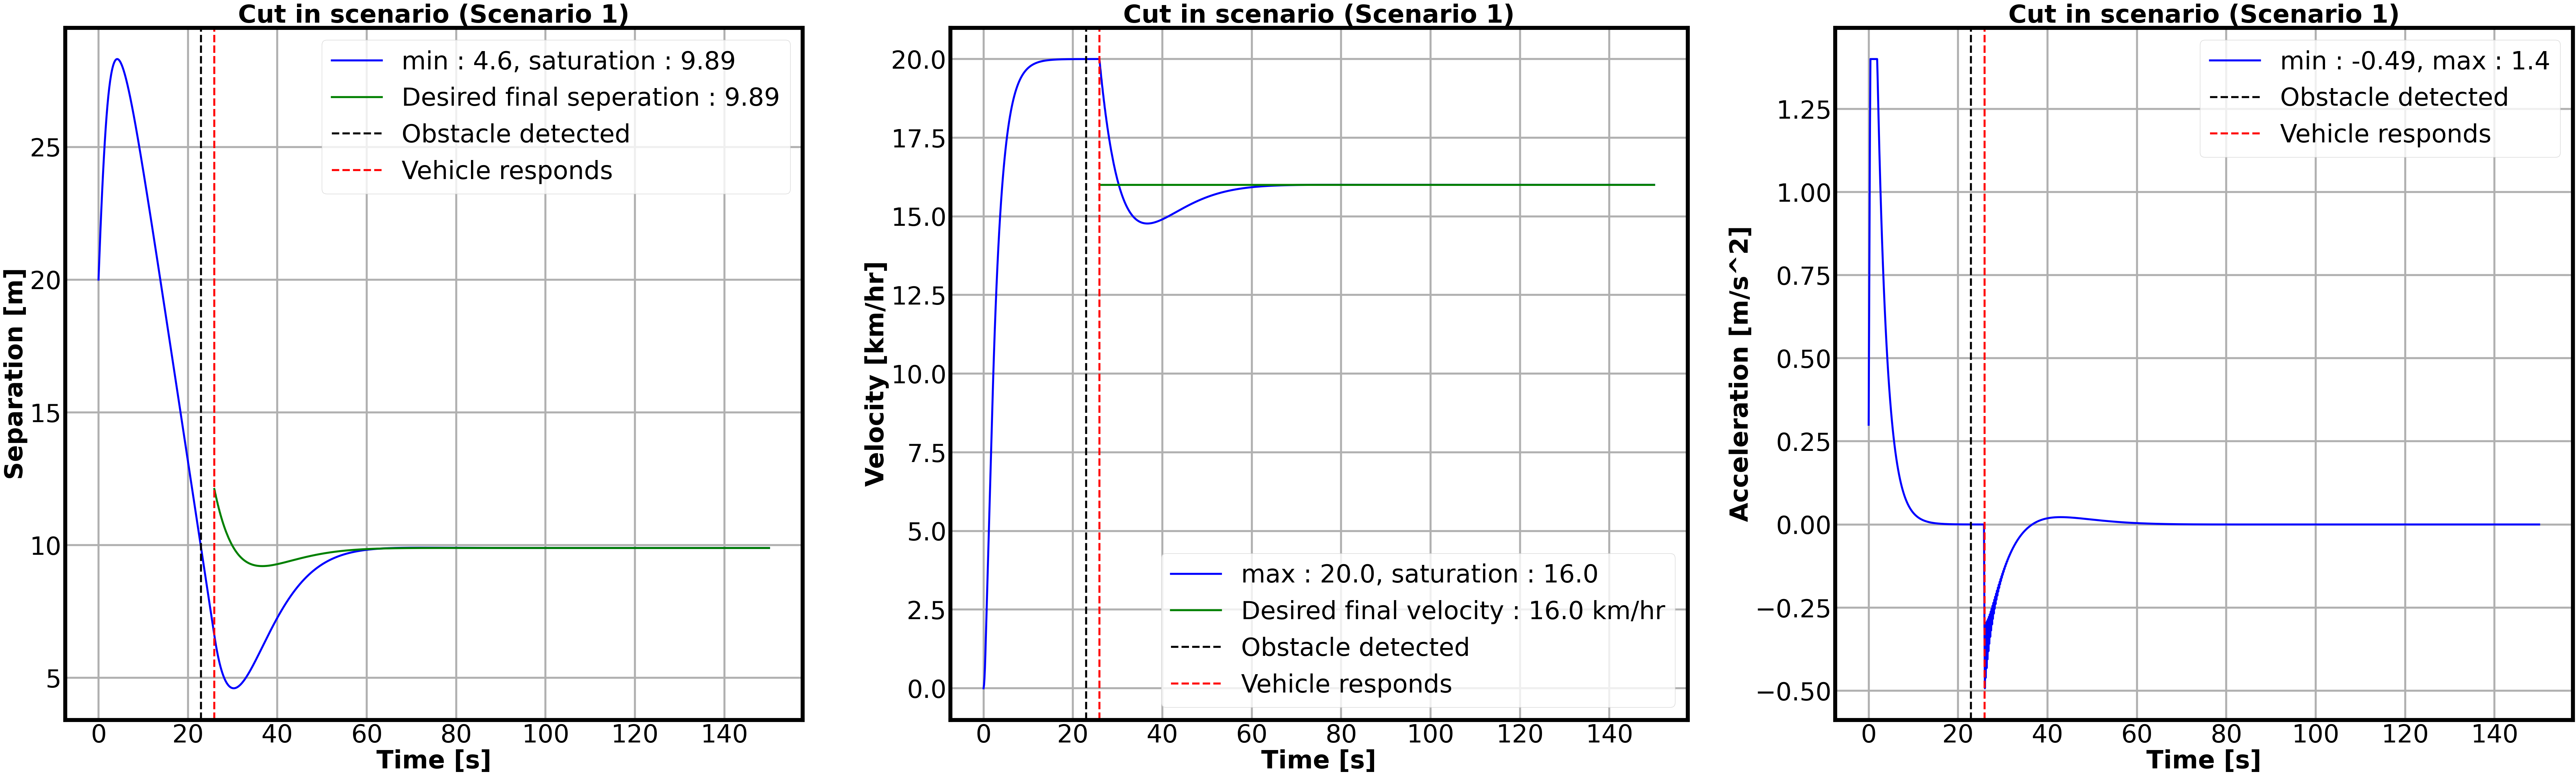

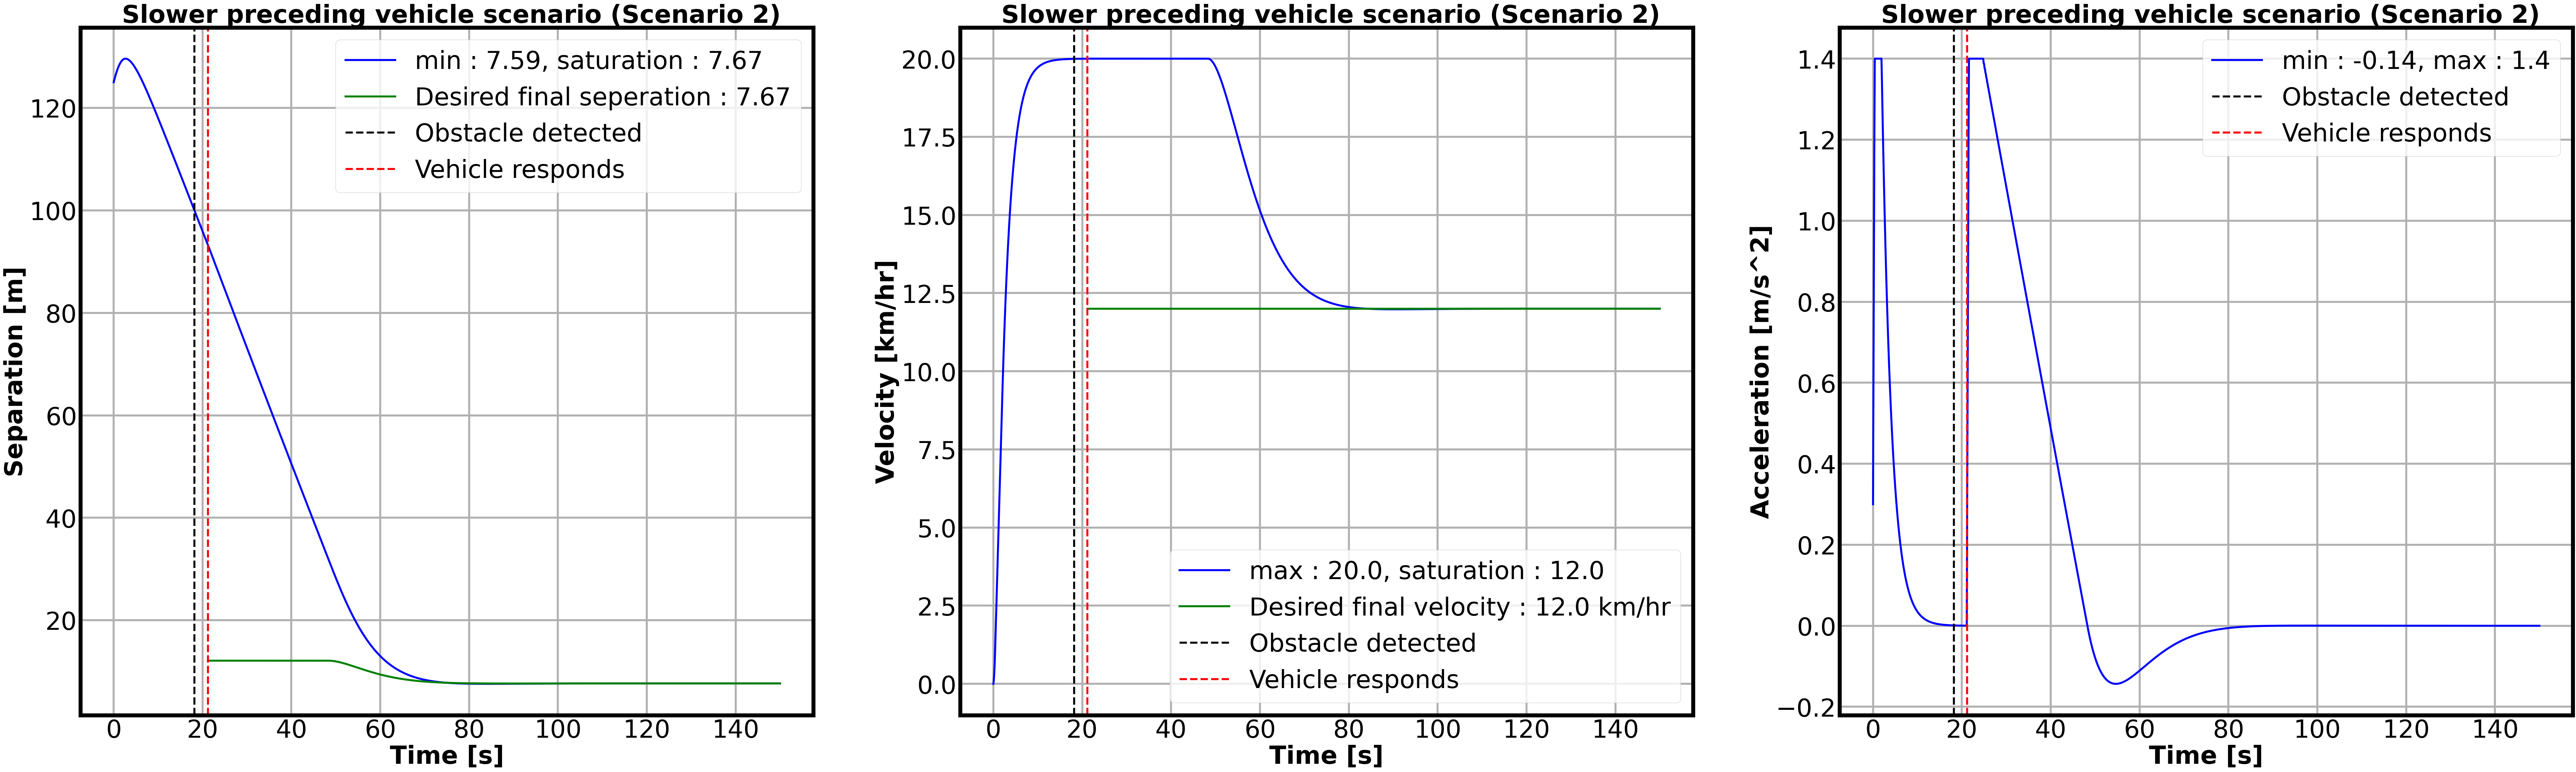

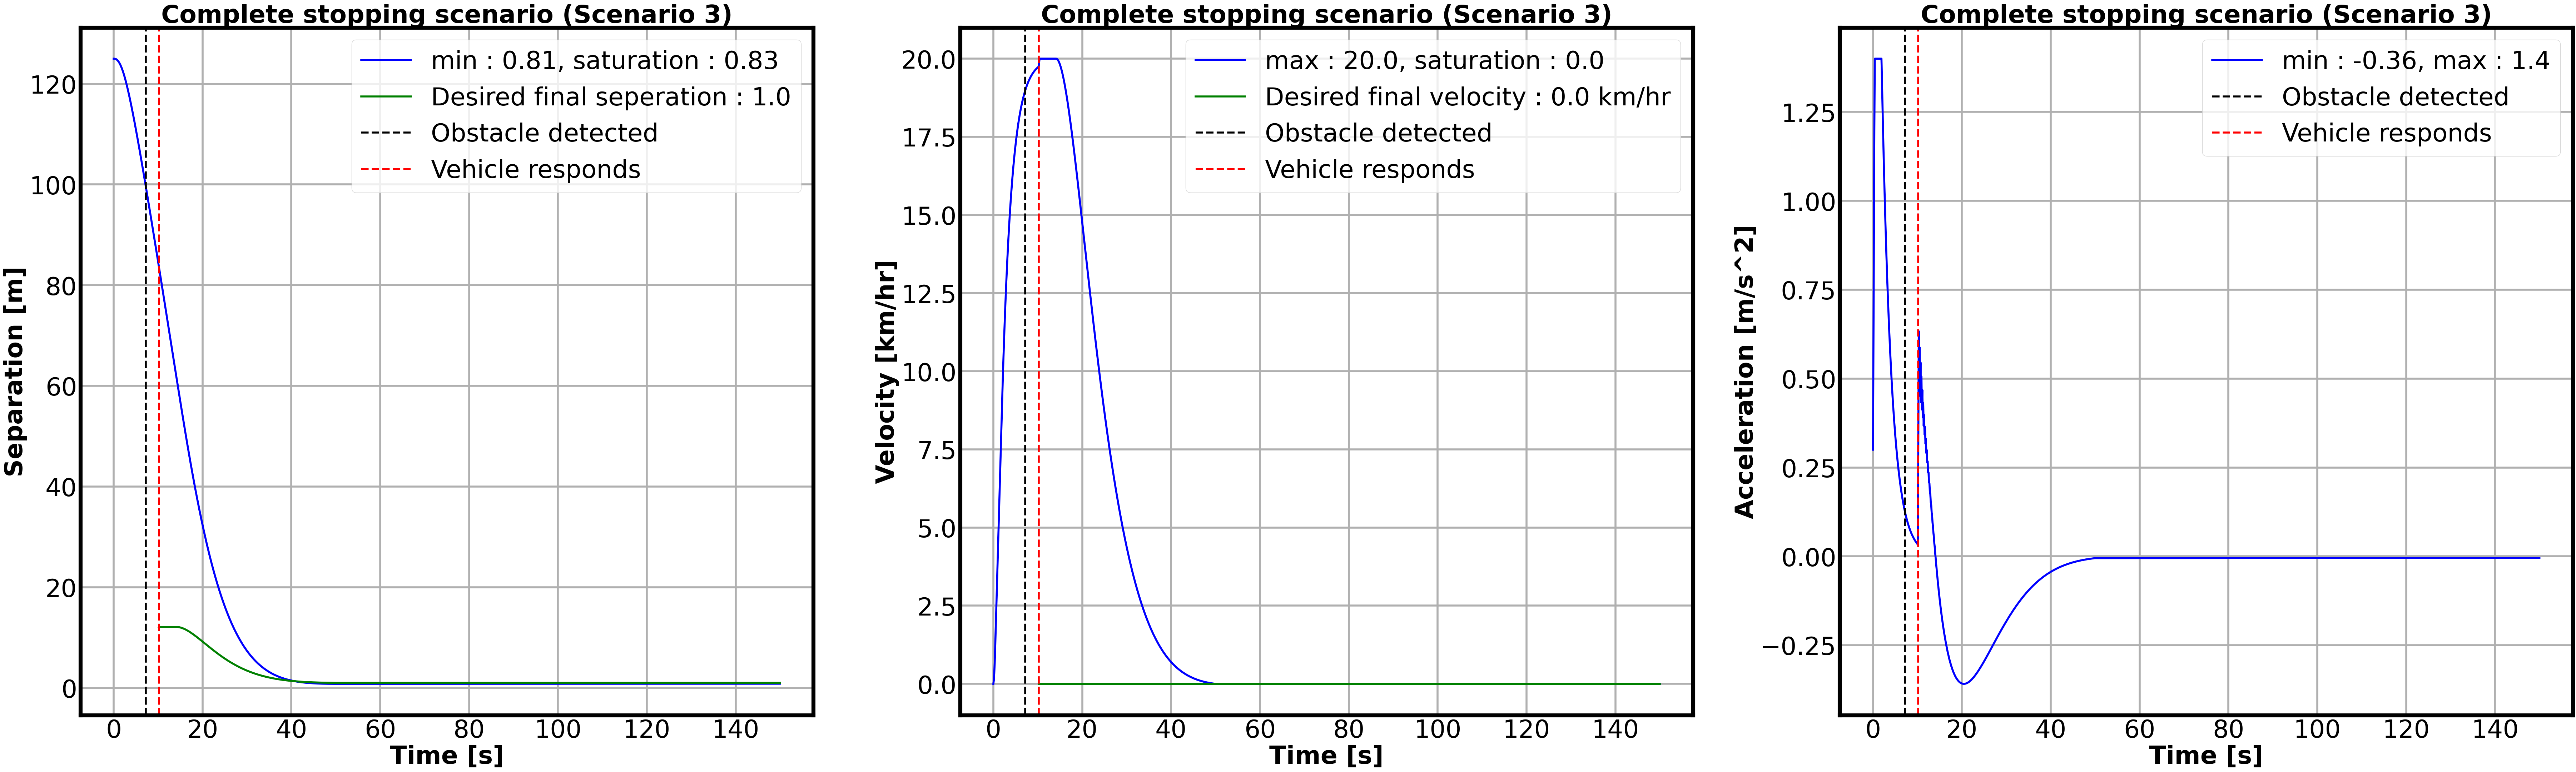

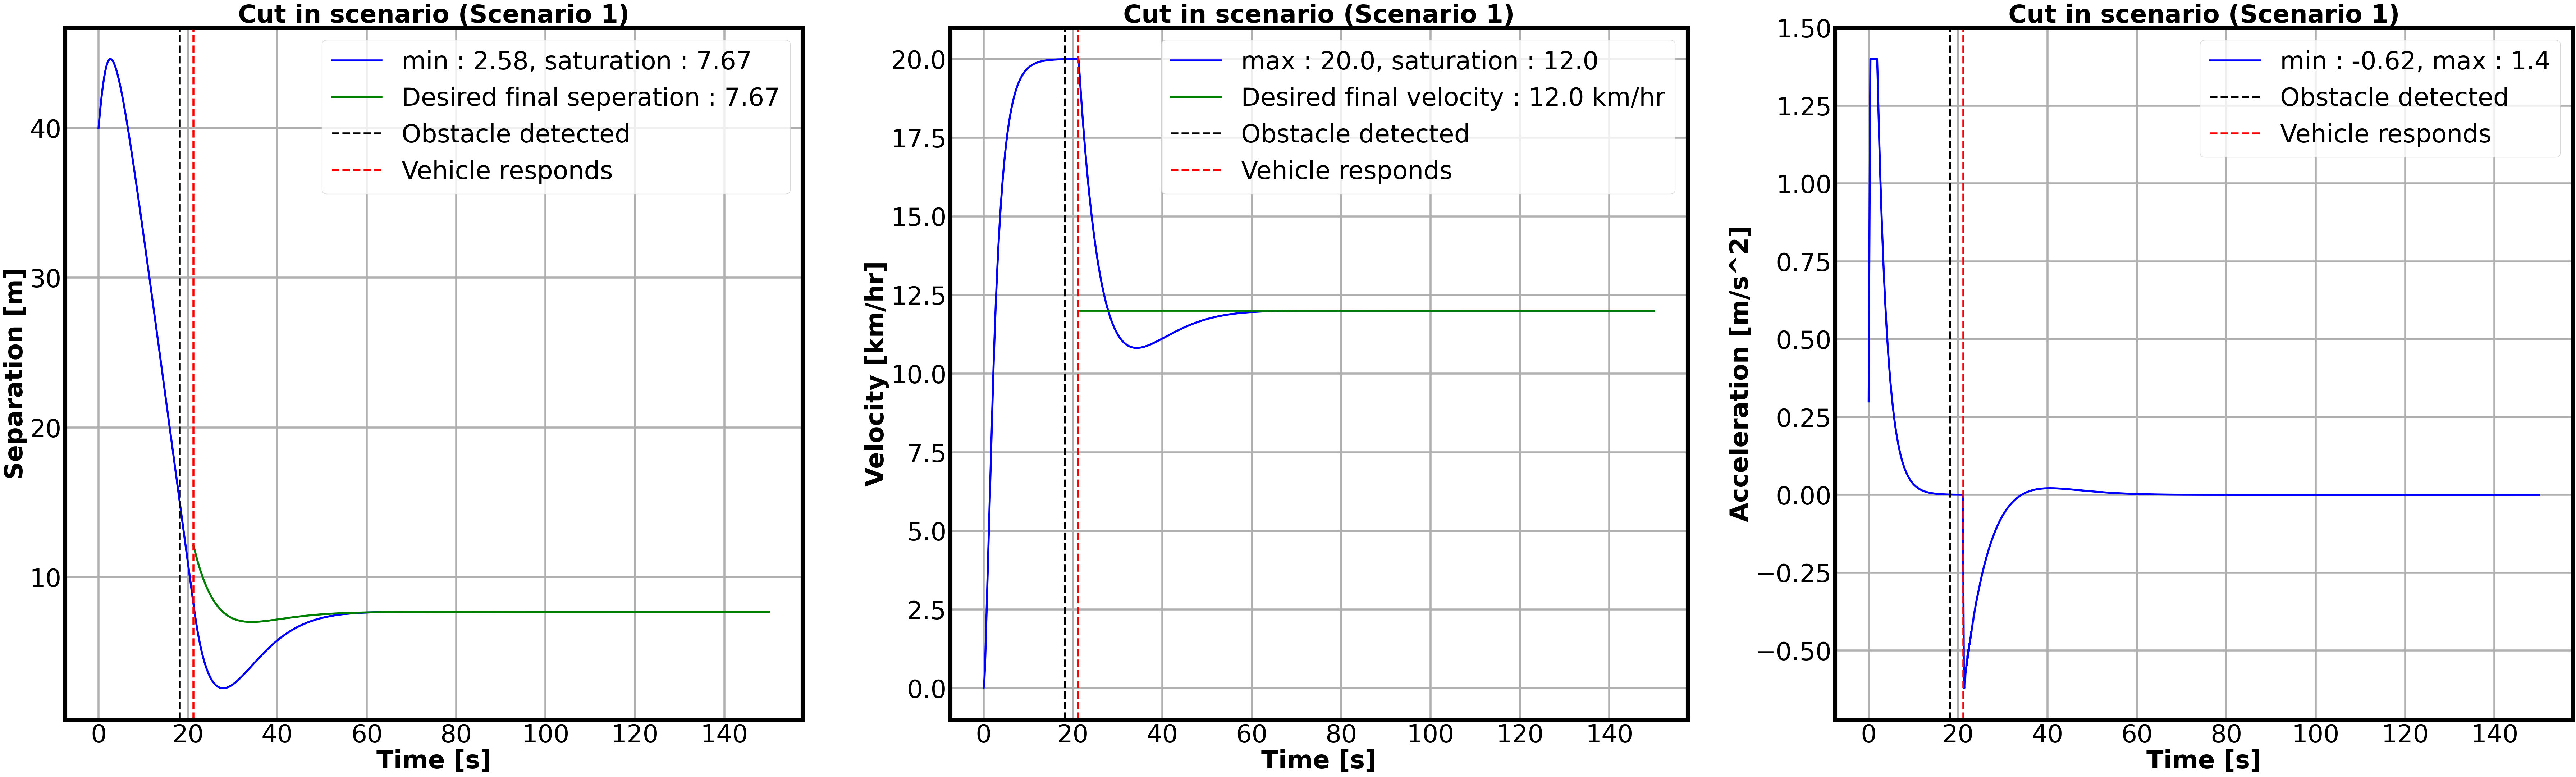

In [5]:
for i in range(len(store_times)):
    plot([store_times[i]], [store_accelerations[i]], [store_velocities[i]], [store_separations[i]], store_detected_times[i], store_start_reaction_times[i], CP.Drs[i], CP.Vps[i], titles[i])

In [6]:
folder_path = os.path.join(internal_WSM_dir, 'store_results_data')
times_file_path = os.path.join(folder_path, 'times.pkl')
separations_file_path = os.path.join(folder_path, 'separations.pkl')
velocities_file_path = os.path.join(folder_path, 'velocities.pkl')
accelerations_file_path = os.path.join(folder_path, 'accelerations.pkl')
detected_times_file_path = os.path.join(folder_path, 'detected_times.pkl')
start_reaction_times_file_path = os.path.join(folder_path, 'start_reaction_times.pkl')

with open(times_file_path, 'wb') as f:
    pickle.dump(store_times, f)
    
with open(separations_file_path, 'wb') as f:
    pickle.dump(store_separations, f)

with open(velocities_file_path, 'wb') as f:
    pickle.dump(store_velocities, f)

with open(accelerations_file_path, 'wb') as f:
    pickle.dump(store_accelerations, f)

with open(detected_times_file_path, 'wb') as f:
    pickle.dump(store_detected_times, f)
    
with open(start_reaction_times_file_path, 'wb') as f:
    pickle.dump(store_start_reaction_times, f)

print(f"The required data has been saved at : {folder_path}")

The required data has been saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\4_PD_Controllers\1_Without_System_model\store_results_data


In [7]:
print(store_separations[2])

[125.0, 124.9985, 124.9925, 124.979, 124.955, 124.918, 124.867, 124.802, 124.723, 124.63, 124.523, 124.402, 124.267, 124.118, 123.955, 123.778, 123.587, 123.382, 123.163, 122.93, 122.68299999999999, np.float64(122.42225701278785), np.float64(122.14832960670695), np.float64(121.861807406894), np.float64(121.56325366964795), np.float64(121.25320646168028), np.float64(120.9321797866276), np.float64(120.60066466118509), np.float64(120.25913014311377), np.float64(119.90802431327383), np.float64(119.54777521374028), np.float64(119.17879174396454), np.float64(118.80146451685864), np.float64(118.41616667659414), np.float64(118.02325467982797), np.float64(117.62306904199068), np.float64(117.21593505019985), np.float64(116.80216344429093), np.float64(116.38205106739144), np.float64(115.95588148740069), np.float64(115.52392559067597), np.float64(115.08644214916842), np.float64(114.6436783621957), np.float64(114.19587037398591), np.float64(113.74324376807621), np.float64(113.2860140396013), np.flo

In [9]:
print(store_velocities[2])

[0.0, 0.10800000000000003, 0.3240000000000001, 0.6480000000000002, 1.08, 1.584, 2.088, 2.592, 3.0960000000000005, 3.6, 4.104, 4.607999999999999, 5.111999999999999, 5.615999999999998, 6.119999999999998, 6.623999999999998, 7.1279999999999974, 7.631999999999996, 8.135999999999997, 8.639999999999997, 9.143999999999998, np.float64(9.629495079274752), np.float64(10.093278158549506), np.float64(10.536320227982811), np.float64(10.959548853733214), np.float64(11.363850119939581), np.float64(11.750070483853417), np.float64(12.11901854800713), np.float64(12.471466753128551), np.float64(12.808152995345987), np.float64(13.129782171069678), np.float64(13.437027652784064), np.float64(13.730532698840587), np.float64(14.010911800202681), np.float64(14.278751966962455), np.float64(14.53461395732263), np.float64(14.779033451616735), np.float64(15.012522173825484), np.float64(15.235568962937467), np.float64(15.4486407963971), np.float64(15.652183767782608), np.float64(15.84662402076091), np.float64(16.032

In [10]:
print(store_accelerations[2])

[0.30000000000000004, 0.6000000000000001, 0.9000000000000001, 1.2000000000000002, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, np.float64(1.3485974424298732), np.float64(1.288286331318762), np.float64(1.2306724150925108), np.float64(1.175635071528897), np.float64(1.1230590727954681), np.float64(1.0728343442050972), np.float64(1.0248557337603172), np.float64(0.9790227920039473), np.float64(0.9352395617150979), np.float64(0.8934143770102566), np.float64(0.8534596714288454), np.float64(0.8152917946014546), np.float64(0.7788308371169216), np.float64(0.7440004632215915), np.float64(0.7107277510004953), np.float64(0.6789430397058422), np.float64(0.64857978391319), np.float64(0.6195744141999497), np.float64(0.5918662040545356), np.float64(0.5653971427375215), np.float64(0.5401118138286166), np.float64(0.5159572792051866), np.float64(0.492882968209414), np.float64(0.4708405717720515), np.float64(0.449783941271108), np.float64(0.42966899191370855), np.float64(